In [ ]:
# !pip install factor_analyzer

In [3]:
import pandas as pd
import numpy as np
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_excel('Cleaned_Dataset 6.xlsx')

# Drop non-numerical columns (IDs, names, etc.) if any
# df = df.drop(columns=['ID', 'Name'])

/opt/anaconda3/lib/python3.12/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


Bartlett's P-Value: 0.0
KMO Overall: 0.8768601765785325


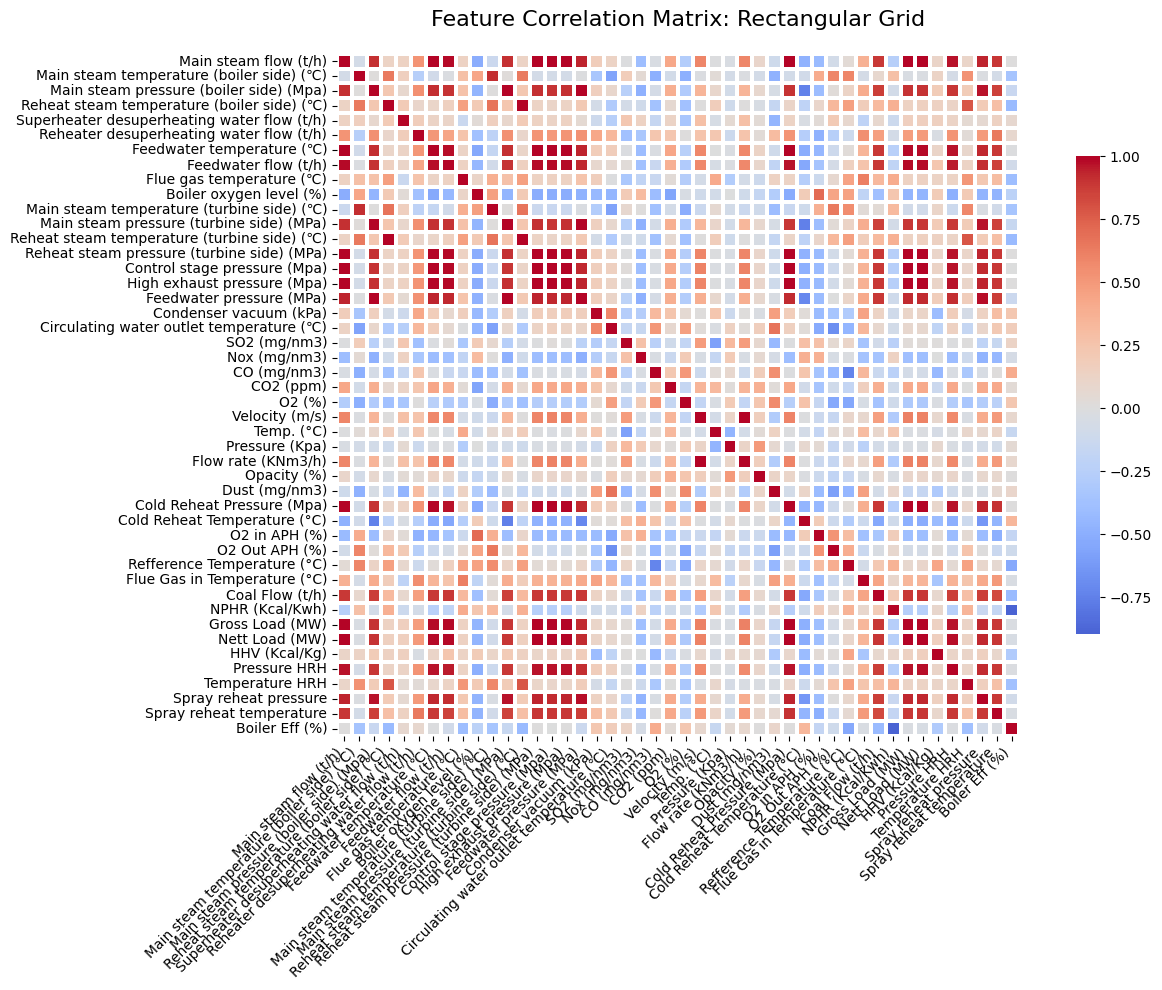

In [4]:
# Select only numeric columns to avoid processing text/IDs
# 1. Select only numeric data
numeric_df = df.select_dtypes(include=[np.number]).dropna()

# Convert to numpy array to bypass the library compatibility error
data_array = numeric_df.values

# 2. Calculate the Correlation Matrix manually
corr_matrix = numeric_df.corr()

# Re-run Factor Suitability (KMO & Bartlett)
chi_square_value, p_value = calculate_bartlett_sphericity(data_array)
kmo_all, kmo_model = calculate_kmo(data_array)
print(f"Bartlett's P-Value: {p_value}")
print(f"KMO Overall: {kmo_model}")

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set the visual style and figure size
plt.figure(figsize=(14, 10))

# 2. Generate the Rectangle Box Heatmap
# We remove 'mask' to show the full rectangle box
sns.heatmap(corr_matrix, 
            annot=False,          # Show the correlation coefficients
            fmt=".2f",           # Format to 2 decimal places
            cmap='coolwarm',       # Red-Blue palette (Standard for EFA)
            center=0,            # 0 is the neutral white color
            square=True,         # Ensures each cell is a perfect square
            linewidths=1.5,      # Thickens the "box" borders
            linecolor='white',   # Adds white borders to create distinct boxes
            cbar_kws={"shrink": .7})

# 3. Add labels and title
plt.title('Feature Correlation Matrix: Rectangular Grid', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') # Rotates labels for better readability
plt.yticks(rotation=0)

plt.tight_layout() #

KMO (0.88) and Bartlett’s Test (p=0.0) are both excellent, data is highly suitable for factor analysis. The warning you received about the "Moore-Penrose generalized matrix inversion" indicates that some of variables are very highly correlated (near-perfect multicollinearity), which is exactly what EFA is meant to resolve by grouping them into factors.

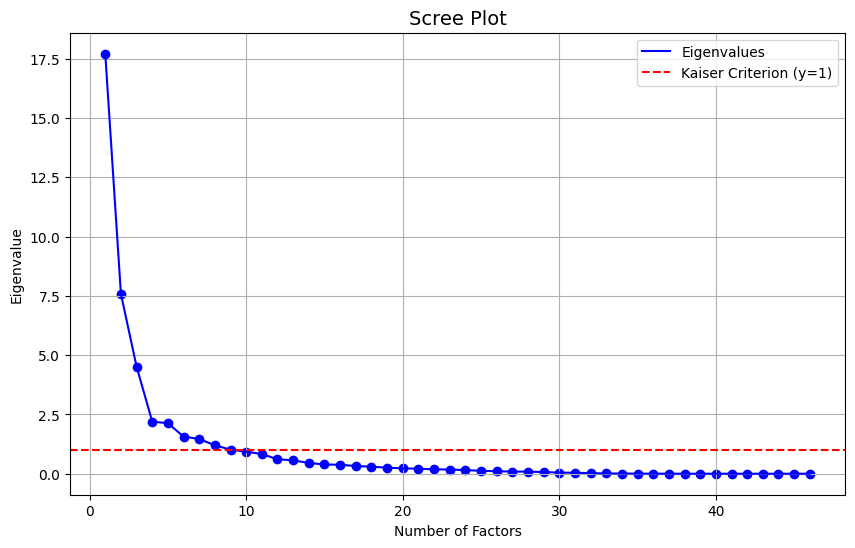

Number of factors with Eigenvalue > 1: 9
Eigenvalues List: [17.714, 7.585, 4.518, 2.197, 2.131, 1.567, 1.465, 1.2, 1.016, 0.927, 0.83, 0.612, 0.564, 0.454, 0.39, 0.379, 0.324, 0.296, 0.255, 0.227, 0.212, 0.185, 0.178, 0.153, 0.123, 0.106, 0.09, 0.088, 0.07, 0.048, 0.04, 0.026, 0.011, 0.008, 0.006, 0.002, 0.001, 0.001, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0]


In [5]:
# 3. Calculate Eigenvalues manually using Numpy
# This completely bypasses the FactorAnalyzer.fit() bug
eigenvalues, eigenvectors = np.linalg.eig(corr_matrix)

# 4. Sort eigenvalues in descending order
ev_sorted = sorted(eigenvalues, reverse=True)

# 5. Plotting the Scree Plot
plt.figure(figsize=(10, 6))
plt.scatter(range(1, len(ev_sorted) + 1), ev_sorted, color='blue')
plt.plot(range(1, len(ev_sorted) + 1), ev_sorted, color='blue', label='Eigenvalues')
plt.title('Scree Plot', fontsize=14)
plt.xlabel('Number of Factors')
plt.ylabel('Eigenvalue')

# Kaiser Criterion line (The standard for feature selection)
plt.axhline(y=1, color='red', linestyle='--', label='Kaiser Criterion (y=1)')
plt.legend()
plt.grid(True)
plt.show()

# 6. Count and print eigenvalues > 1
n_factors_recommended = len([i for i in ev_sorted if i > 1])
print(f"Number of factors with Eigenvalue > 1: {n_factors_recommended}")
print("Eigenvalues List:", [round(x, 3) for x in ev_sorted])

In [6]:
# Use the n_factors_recommended from the previous step
n = n_factors_recommended 

# Calculate the Loadings for the top 'n' factors
# We take the first 'n' eigenvectors and scale them by sqrt(eigenvalues)
extracted_loadings = eigenvectors[:, :n] * np.sqrt(ev_sorted[:n])

# Create a clean DataFrame for the Pattern Matrix
pattern_matrix = pd.DataFrame(
    extracted_loadings, 
    index=numeric_df.columns, 
    columns=[f'Factor_{i+1}' for i in range(n)]
)

print("--- Manual Pattern Matrix (Feature Loadings) ---")
print(pattern_matrix.round(3))

--- Manual Pattern Matrix (Feature Loadings) ---
                                             Factor_1  Factor_2  Factor_3  \
Main steam flow (t/h)                           0.984    -0.028     0.120   
Main steam temperature (boiler side) (℃)       -0.054     0.838    -0.011   
Main steam pressure (boiler side) (Mpa)         0.946     0.087    -0.119   
Reheat steam temperature (boiler side) (℃)      0.195     0.711    -0.346   
Superheater desuperheating water flow (t/h)     0.132     0.241     0.356   
Reheater desuperheating water flow (t/h)        0.579    -0.245    -0.333   
Feedwater temperature (℃)                       0.982    -0.053     0.116   
Feedwater flow (t/h)                            0.963     0.066     0.168   
Flue gas temperature (℃)                        0.228     0.383    -0.639   
Boiler oxygen level (%)                        -0.525     0.553     0.115   
Main steam temperature (turbine side) (℃)      -0.093     0.834    -0.143   
Main steam pressure (turbin

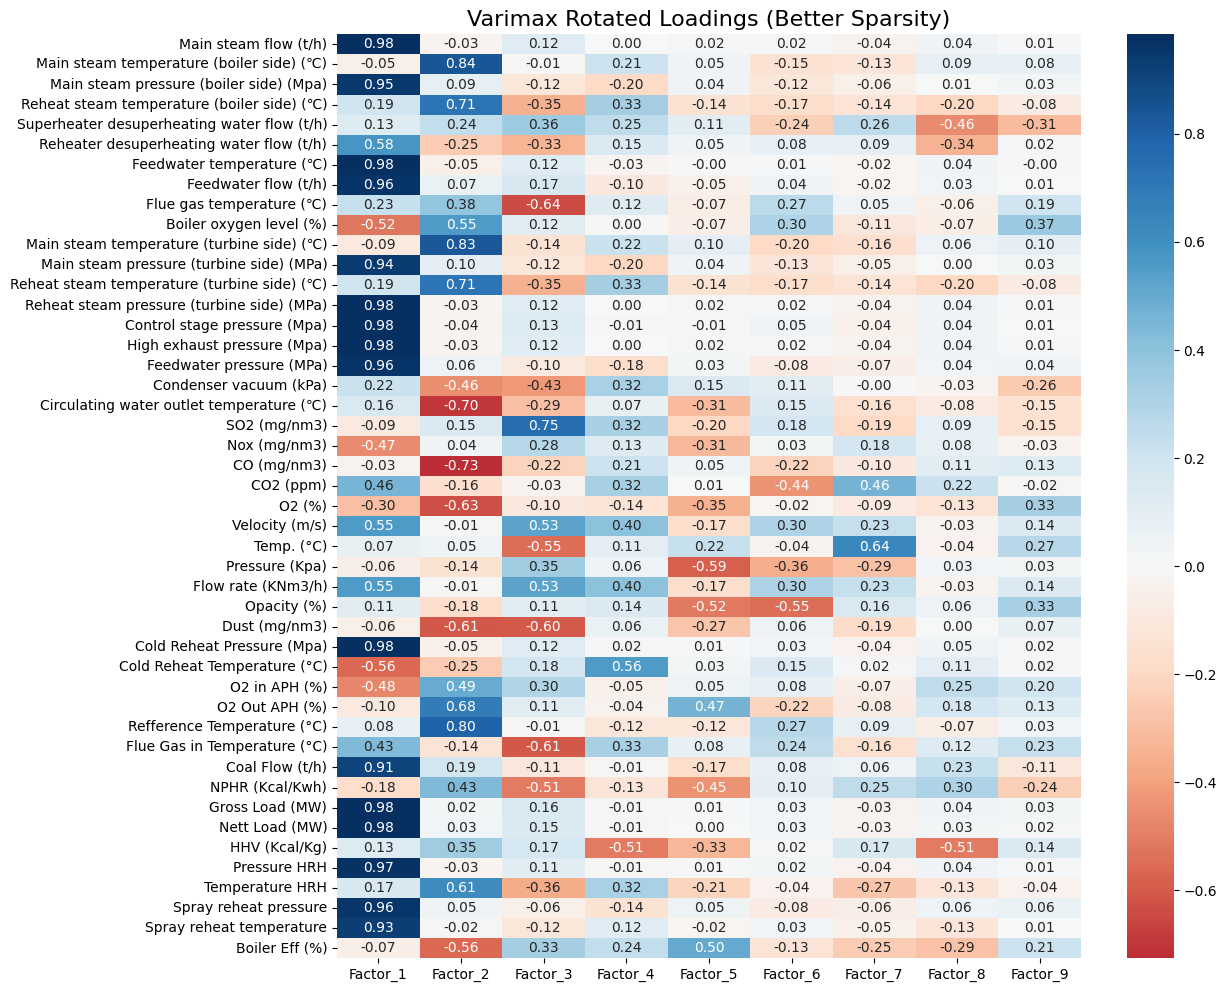

In [7]:
# 4. Visualisasi dengan Heatmap untuk melihat perbedaan
plt.figure(figsize=(12, 12))
sns.heatmap(pattern_matrix, annot=True, cmap='RdBu', center=0, fmt='.2f')
plt.title('Varimax Rotated Loadings (Better Sparsity)', fontsize=16)
plt.show()

--- Rotated Pattern Matrix (Varimax Orthogonal) ---
                                             Factor_1  Factor_2  Factor_3  \
Main steam flow (t/h)                           0.981     0.009    -0.052   
Main steam temperature (boiler side) (℃)       -0.044     0.648     0.611   
Main steam pressure (boiler side) (Mpa)         0.958     0.107    -0.020   
Reheat steam temperature (boiler side) (℃)      0.130     0.898     0.141   
Superheater desuperheating water flow (t/h)     0.079     0.172     0.154   
Reheater desuperheating water flow (t/h)        0.492     0.147    -0.486   
Feedwater temperature (℃)                       0.980    -0.020    -0.074   
Feedwater flow (t/h)                            0.973     0.003     0.021   
Flue gas temperature (℃)                        0.159     0.566    -0.102   
Boiler oxygen level (%)                        -0.504     0.286     0.451   
Main steam temperature (turbine side) (℃)      -0.089     0.714     0.574   
Main steam pressure (tur

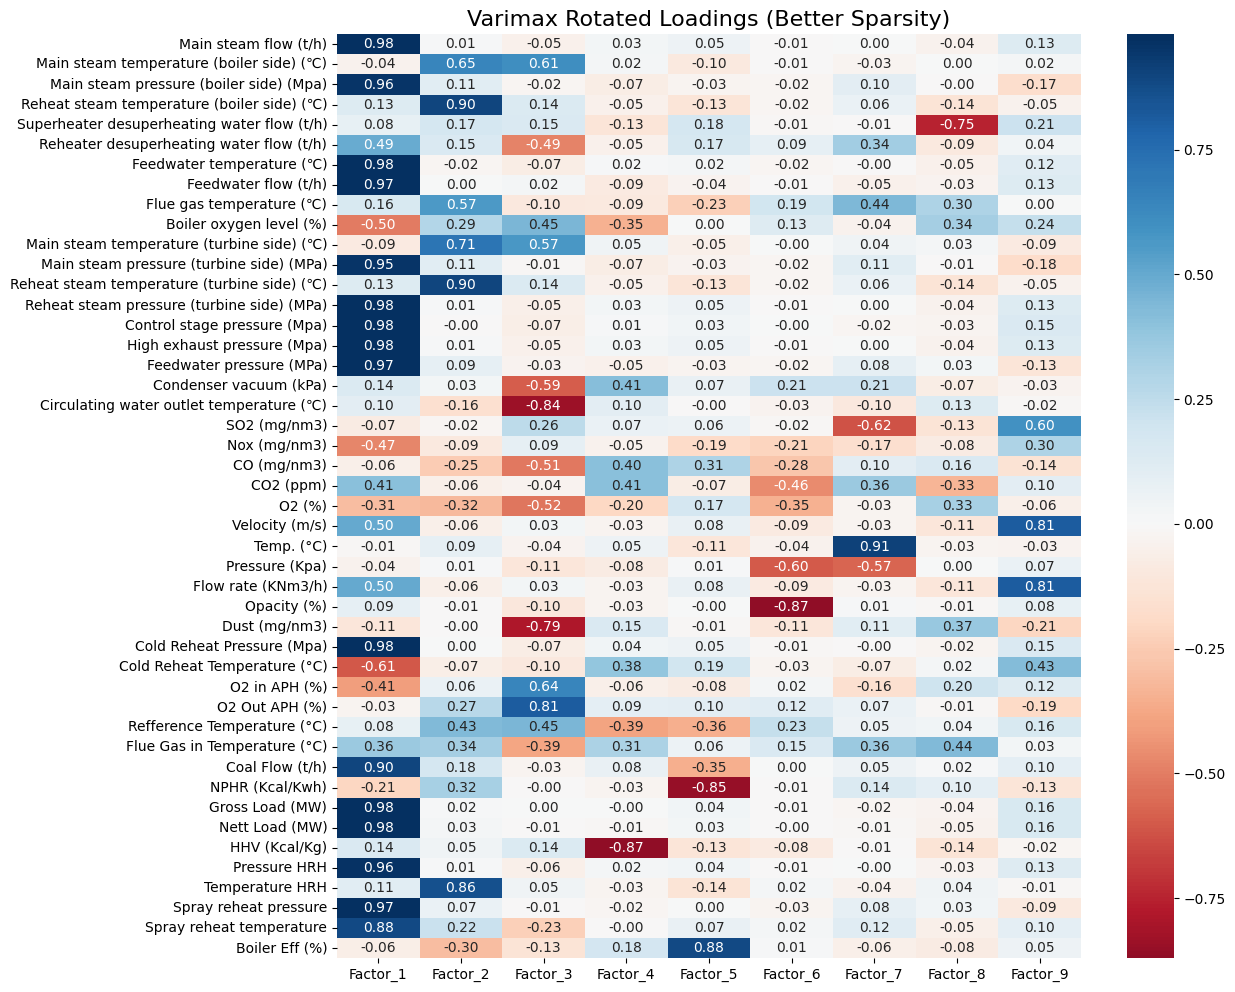

In [8]:
from factor_analyzer import Rotator
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Inisialisasi Rotator Varimax
rotator = Rotator(method='varimax')

# 2. Lakukan Rotasi pada Loading yang sudah diekstrak (n=6)
# extracted_loadings adalah hasil dari langkah sebelumnya (eigenvectors * sqrt(ev))
rotated_loadings = rotator.fit_transform(extracted_loadings)

# 3. Buat Dataframe Pattern Matrix yang sudah Terotasi
rotated_pattern_matrix = pd.DataFrame(
    rotated_loadings,
    index=numeric_df.columns,
    columns=[f'Factor_{i+1}' for i in range(n)]
)

print("--- Rotated Pattern Matrix (Varimax Orthogonal) ---")
print(rotated_pattern_matrix.round(3))

# 4. Visualisasi dengan Heatmap untuk melihat perbedaan
plt.figure(figsize=(12, 12))
sns.heatmap(rotated_pattern_matrix, annot=True, cmap='RdBu', center=0, fmt='.2f')
plt.title('Varimax Rotated Loadings (Better Sparsity)', fontsize=16)
plt.show()

In [9]:
# 2. Seleksi fitur dengan loading > 0.5 (Absolute)
threshold = 0.5
selected_features = []

for col in rotated_pattern_matrix.columns:
    # Ambil fitur yang signifikan di tiap faktor
    top_features = rotated_pattern_matrix[abs(rotated_pattern_matrix[col]) >= threshold].index.tolist()
    selected_features.extend(top_features)

# 3. Pembersihan: Hapus duplikat dan buang target
selected_features = list(set(selected_features))
targets = ['Boiler Eff (%)', 'NPHR (Kcal/Kwh)']
final_inputs = [f for f in selected_features if f not in targets]

print(f"Total fitur terpilih untuk model: {len(final_inputs)}")
print("Daftar Fitur:", final_inputs)
final_inputs

Total fitur terpilih untuk model: 39
Daftar Fitur: ['Cold Reheat Temperature (°C)', 'Spray reheat pressure', 'Feedwater temperature (℃)', 'Condenser vacuum (kPa)', 'Main steam temperature (turbine side) (℃)', 'Control stage pressure (Mpa)', 'O2 Out APH (%)', 'Superheater desuperheating water flow (t/h)', 'Flow rate (KNm3/h)', 'Main steam flow (t/h)', 'Coal Flow (t/h)', 'SO2 (mg/nm3)', 'Temp. (°C)', 'Gross Load (MW)', 'Feedwater pressure (MPa)', 'Reheat steam temperature (turbine side) (℃)', 'Velocity (m/s)', 'Circulating water outlet temperature (℃)', 'Main steam pressure (boiler side) (Mpa)', 'High exhaust pressure (Mpa)', 'Main steam pressure (turbine side) (MPa)', 'CO (mg/nm3)', 'Pressure HRH', 'O2 in APH (%)', 'Boiler oxygen level (%)', 'Feedwater flow (t/h)', 'Nett Load (MW)', 'Opacity (%)', 'Flue gas temperature (℃)', 'Spray reheat temperature', 'O2 (%)', 'HHV (Kcal/Kg)', 'Reheat steam pressure (turbine side) (MPa)', 'Reheat steam temperature (boiler side) (℃)', 'Main steam tempe

['Cold Reheat Temperature (°C)',
 'Spray reheat pressure',
 'Feedwater temperature (℃)',
 'Condenser vacuum (kPa)',
 'Main steam temperature (turbine side) (℃)',
 'Control stage pressure (Mpa)',
 'O2 Out APH (%)',
 'Superheater desuperheating water flow (t/h)',
 'Flow rate (KNm3/h)',
 'Main steam flow (t/h)',
 'Coal Flow (t/h)',
 'SO2 (mg/nm3)',
 'Temp. (°C)',
 'Gross Load (MW)',
 'Feedwater pressure (MPa)',
 'Reheat steam temperature (turbine side) (℃)',
 'Velocity (m/s)',
 'Circulating water outlet temperature (℃)',
 'Main steam pressure (boiler side) (Mpa)',
 'High exhaust pressure (Mpa)',
 'Main steam pressure (turbine side) (MPa)',
 'CO (mg/nm3)',
 'Pressure HRH',
 'O2 in APH (%)',
 'Boiler oxygen level (%)',
 'Feedwater flow (t/h)',
 'Nett Load (MW)',
 'Opacity (%)',
 'Flue gas temperature (℃)',
 'Spray reheat temperature',
 'O2 (%)',
 'HHV (Kcal/Kg)',
 'Reheat steam pressure (turbine side) (MPa)',
 'Reheat steam temperature (boiler side) (℃)',
 'Main steam temperature (boiler si

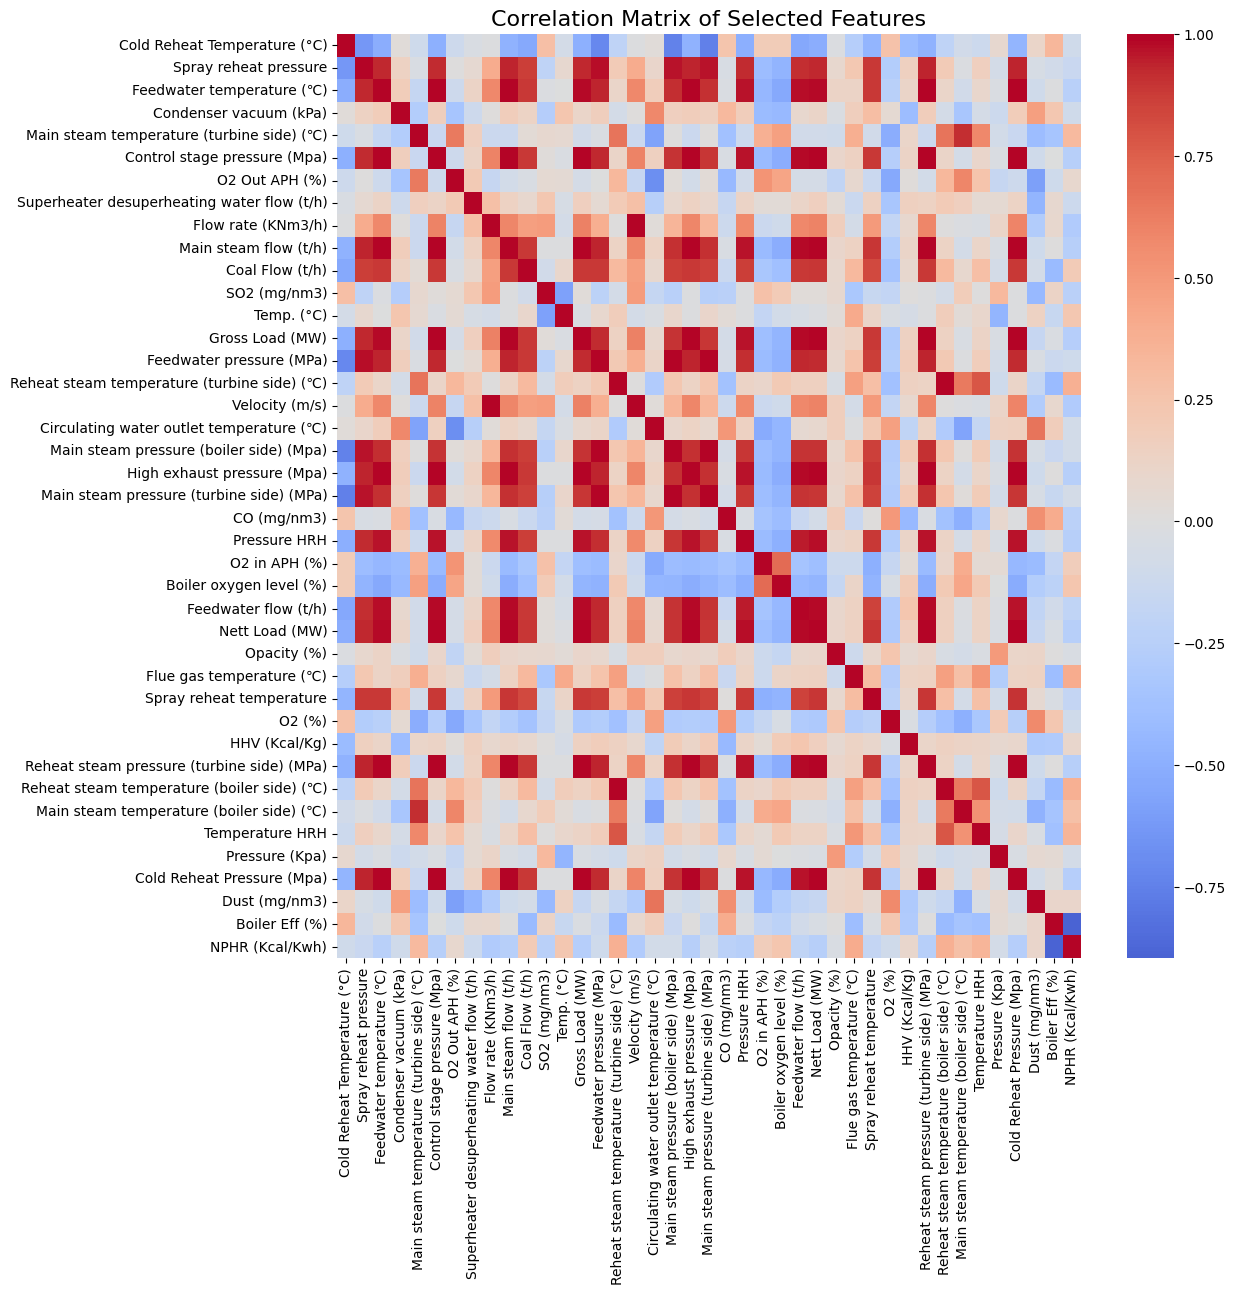

In [10]:
# --- 1. Jalankan Perhitungan Korelasi ---
corr_matrix = numeric_df[final_inputs + ['Boiler Eff (%)', 'NPHR (Kcal/Kwh)']].corr()

# 4. Visualisasi dengan Heatmap untuk melihat perbedaan
plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Selected Features', fontsize=16)
plt.show()

Total kandidat fitur: 39
---
Fitur terpilih untuk Boiler Eff (Hubungan Terkuat): 16
Daftar: ['Cold Reheat Temperature (°C)', 'Condenser vacuum (kPa)', 'Main steam temperature (turbine side) (℃)', 'O2 Out APH (%)', 'Coal Flow (t/h)', 'Feedwater pressure (MPa)', 'Reheat steam temperature (turbine side) (℃)', 'Circulating water outlet temperature (℃)', 'Main steam pressure (boiler side) (Mpa)', 'Main steam pressure (turbine side) (MPa)', 'CO (mg/nm3)', 'O2 (%)', 'HHV (Kcal/Kg)', 'Reheat steam temperature (boiler side) (℃)', 'Main steam temperature (boiler side) (℃)', 'Temperature HRH']

Fitur terpilih untuk NPHR (Hubungan Terkuat): 23
Daftar: ['Spray reheat pressure', 'Feedwater temperature (℃)', 'Control stage pressure (Mpa)', 'Superheater desuperheating water flow (t/h)', 'Flow rate (KNm3/h)', 'Main steam flow (t/h)', 'SO2 (mg/nm3)', 'Temp. (°C)', 'Gross Load (MW)', 'Velocity (m/s)', 'High exhaust pressure (Mpa)', 'Pressure HRH', 'O2 in APH (%)', 'Boiler oxygen level (%)', 'Feedwater fl

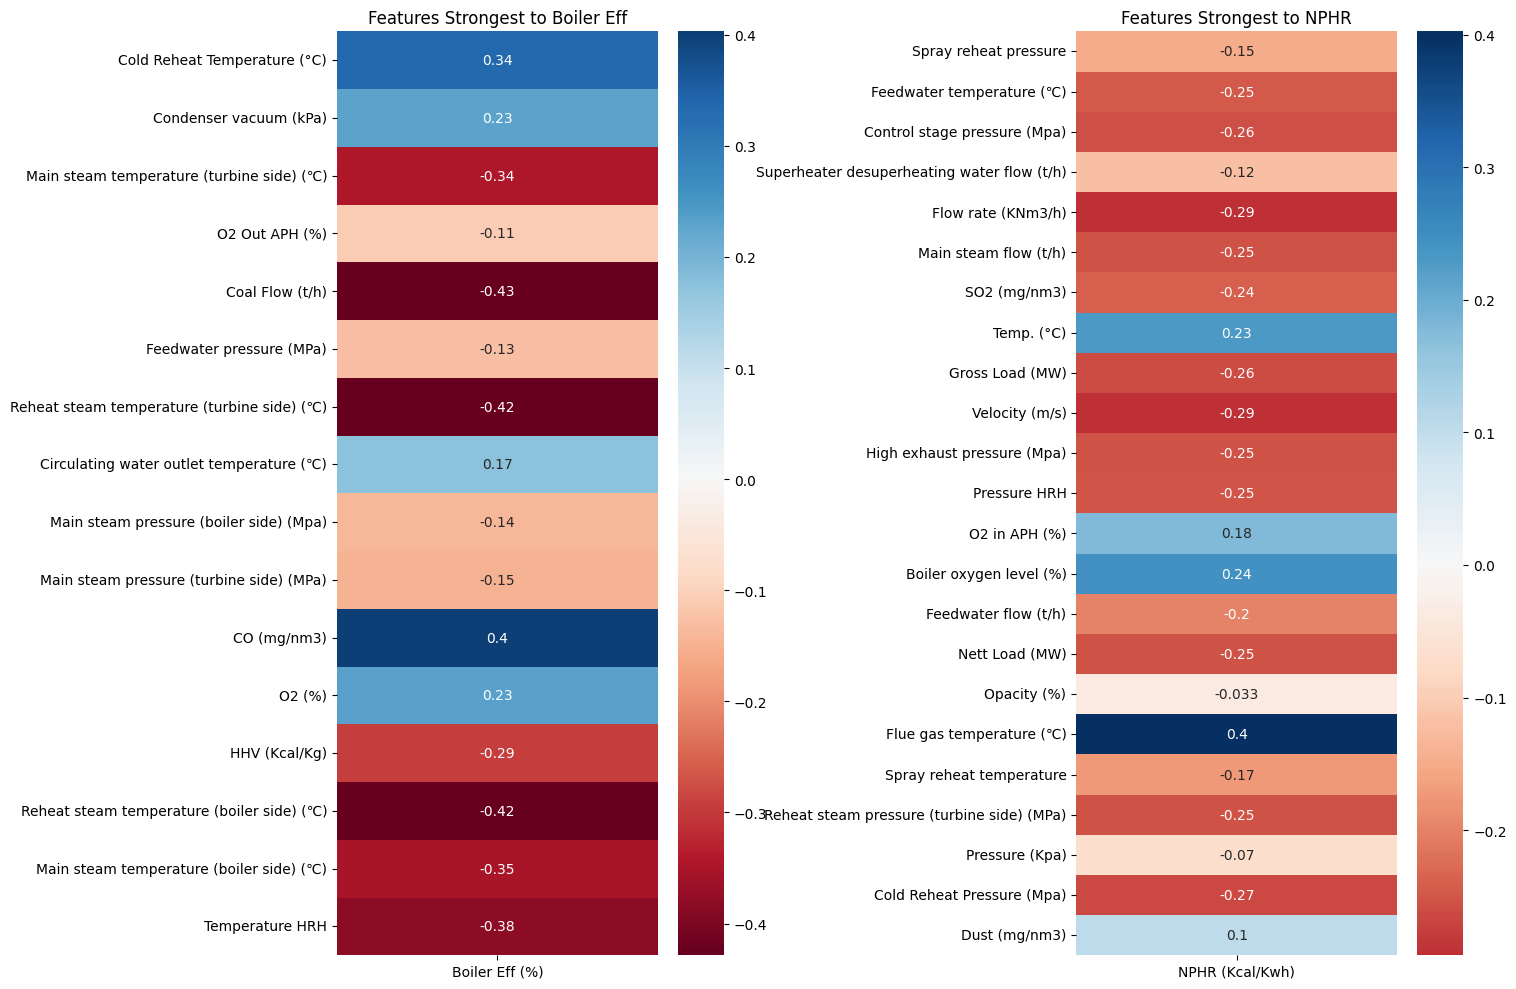

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Persiapan Data ---
candidates = [f for f in final_inputs if f not in ['Boiler Eff (%)', 'NPHR (Kcal/Kwh)']]
targets = ['Boiler Eff (%)', 'NPHR (Kcal/Kwh)']

# Hitung korelasi
corr_matrix = df[candidates + targets].corr()

# --- 2. Pemisahan Berdasarkan Korelasi Tertinggi (Tanpa Threshold) ---
inputs_for_boiler = []
inputs_for_nphr = []

for feature in candidates:
    corr_to_boiler = abs(corr_matrix.loc[feature, 'Boiler Eff (%)'])
    corr_to_nphr = abs(corr_matrix.loc[feature, 'NPHR (Kcal/Kwh)'])
    
    # Bandingkan mana yang lebih kuat
    if corr_to_boiler > corr_to_nphr:
        inputs_for_boiler.append(feature)
    else:
        inputs_for_nphr.append(feature)

# --- 3. Print Hasil ---
print(f"Total kandidat fitur: {len(candidates)}")
print(f"---")
print(f"Fitur terpilih untuk Boiler Eff (Hubungan Terkuat): {len(inputs_for_boiler)}")
print(f"Daftar: {inputs_for_boiler}\n")
print(f"Fitur terpilih untuk NPHR (Hubungan Terkuat): {len(inputs_for_nphr)}")
print(f"Daftar: {inputs_for_nphr}")

# --- 4. Visualisasi Perbandingan ---
# Kita visualisasikan fitur Boiler Eff dan NPHR secara terpisah untuk melihat kontrasnya
fig, ax = plt.subplots(1, 2, figsize=(15, 10))

# Heatmap untuk Boiler Eff Features
if inputs_for_boiler:
    sns.heatmap(corr_matrix.loc[inputs_for_boiler, ['Boiler Eff (%)']], 
                annot=True, cmap='RdBu', center=0, ax=ax[0])
    ax[0].set_title('Features Strongest to Boiler Eff')

# Heatmap untuk NPHR Features
if inputs_for_nphr:
    sns.heatmap(corr_matrix.loc[inputs_for_nphr, ['NPHR (Kcal/Kwh)']], 
                annot=True, cmap='RdBu', center=0, ax=ax[1])
    ax[1].set_title('Features Strongest to NPHR')

plt.tight_layout()
plt.show()

In [12]:
print(f"Fitur terpilih untuk Boiler Eff (Hubungan Terkuat): {len(inputs_for_boiler)}")
inputs_for_boiler

Fitur terpilih untuk Boiler Eff (Hubungan Terkuat): 16


['Cold Reheat Temperature (°C)',
 'Condenser vacuum (kPa)',
 'Main steam temperature (turbine side) (℃)',
 'O2 Out APH (%)',
 'Coal Flow (t/h)',
 'Feedwater pressure (MPa)',
 'Reheat steam temperature (turbine side) (℃)',
 'Circulating water outlet temperature (℃)',
 'Main steam pressure (boiler side) (Mpa)',
 'Main steam pressure (turbine side) (MPa)',
 'CO (mg/nm3)',
 'O2 (%)',
 'HHV (Kcal/Kg)',
 'Reheat steam temperature (boiler side) (℃)',
 'Main steam temperature (boiler side) (℃)',
 'Temperature HRH']

In [13]:
print(f"Fitur terpilih untuk NPHR (Hubungan Terkuat): {len(inputs_for_nphr)}")
inputs_for_nphr

Fitur terpilih untuk NPHR (Hubungan Terkuat): 23


['Spray reheat pressure',
 'Feedwater temperature (℃)',
 'Control stage pressure (Mpa)',
 'Superheater desuperheating water flow (t/h)',
 'Flow rate (KNm3/h)',
 'Main steam flow (t/h)',
 'SO2 (mg/nm3)',
 'Temp. (°C)',
 'Gross Load (MW)',
 'Velocity (m/s)',
 'High exhaust pressure (Mpa)',
 'Pressure HRH',
 'O2 in APH (%)',
 'Boiler oxygen level (%)',
 'Feedwater flow (t/h)',
 'Nett Load (MW)',
 'Opacity (%)',
 'Flue gas temperature (℃)',
 'Spray reheat temperature',
 'Reheat steam pressure (turbine side) (MPa)',
 'Pressure (Kpa)',
 'Cold Reheat Pressure (Mpa)',
 'Dust (mg/nm3)']

Fitur yang BISA digunakan di KEDUA model: 8
Daftar Shared: ['Flue gas temperature (℃)', 'CO (mg/nm3)', 'Main steam temperature (turbine side) (℃)', 'Reheat steam temperature (turbine side) (℃)', 'Reheat steam temperature (boiler side) (℃)', 'Boiler oxygen level (%)', 'Main steam temperature (boiler side) (℃)', 'Temperature HRH']

Fitur UNIK untuk Boiler saja: ['Cold Reheat Temperature (°C)', 'Condenser vacuum (kPa)', 'HHV (Kcal/Kg)', 'O2 (%)', 'Coal Flow (t/h)']
Fitur UNIK untuk NPHR saja: ['Nett Load (MW)', 'Feedwater temperature (℃)', 'Temp. (°C)', 'Gross Load (MW)', 'Pressure HRH', 'Reheat steam pressure (turbine side) (MPa)', 'Control stage pressure (Mpa)', 'Velocity (m/s)', 'High exhaust pressure (Mpa)', 'Cold Reheat Pressure (Mpa)', 'Flow rate (KNm3/h)', 'Main steam flow (t/h)', 'SO2 (mg/nm3)']


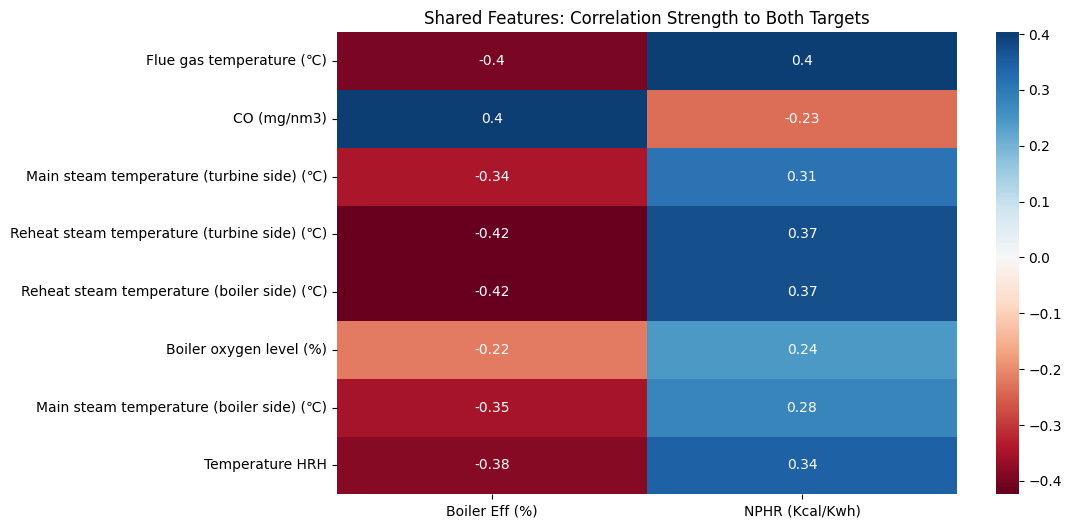

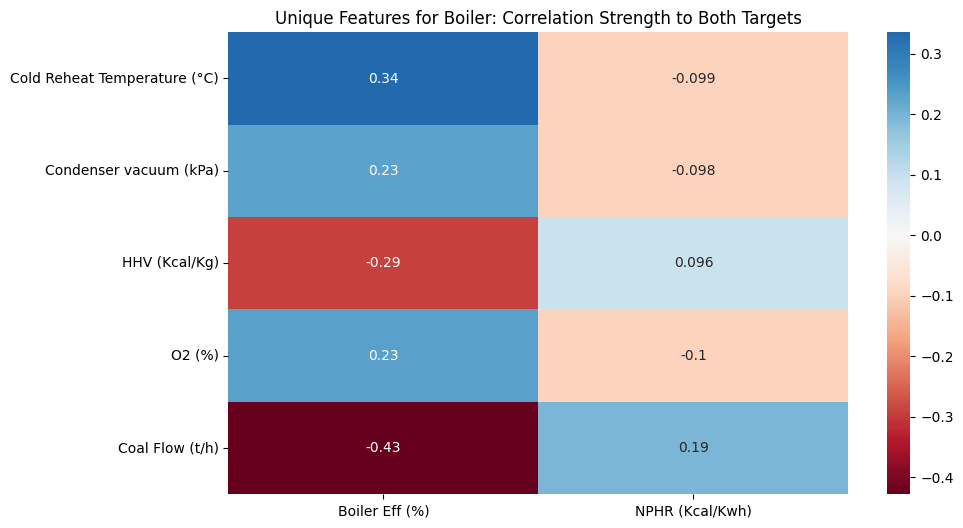

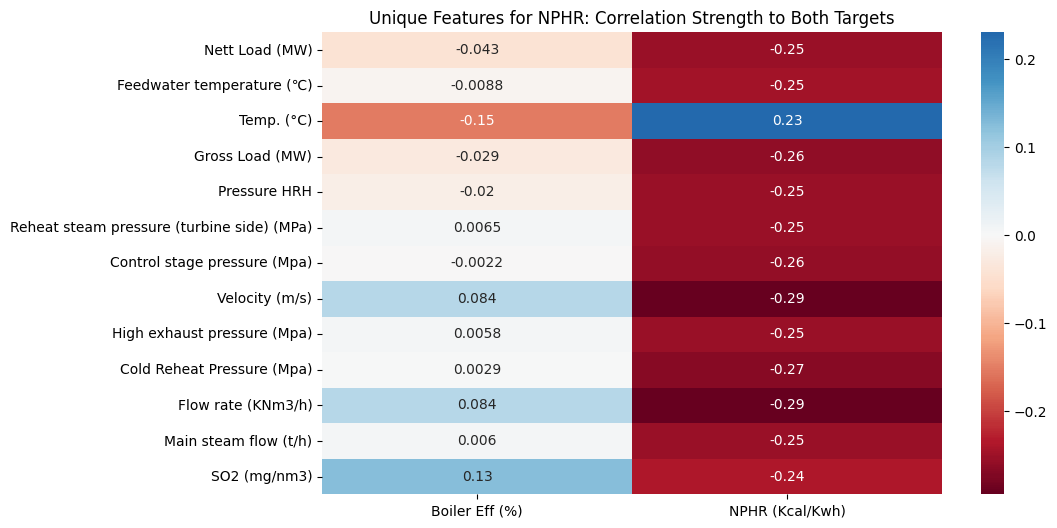

In [14]:
# --- 1. Tentukan Fitur yang Signifikan untuk Masing-Masing (EFA + Correlation) ---
# Kita gunakan threshold kecil (misal 0.2) untuk melihat potensi fitur "Shared"
threshold_shared = 0.2

sig_boiler = corr_matrix[abs(corr_matrix['Boiler Eff (%)']) >= threshold_shared].index.tolist()
sig_nphr = corr_matrix[abs(corr_matrix['NPHR (Kcal/Kwh)']) >= threshold_shared].index.tolist()

# Bersihkan dari target itu sendiri
sig_boiler = [f for f in sig_boiler if f not in targets]
sig_nphr = [f for f in sig_nphr if f not in targets]

# --- 2. Cari Irisan (Intersection) ---
shared_features = list(set(sig_boiler) & set(sig_nphr))
only_boiler = list(set(sig_boiler) - set(sig_nphr))
only_nphr = list(set(sig_nphr) - set(sig_boiler))

# --- 3. Print Hasil Analisis ---
print(f"Fitur yang BISA digunakan di KEDUA model: {len(shared_features)}")
print(f"Daftar Shared: {shared_features}\n")

print(f"Fitur UNIK untuk Boiler saja: {only_boiler}")
print(f"Fitur UNIK untuk NPHR saja: {only_nphr}")

# --- 4. Visualisasi Venn Diagram Sederhana via Heatmap ---
plt.figure(figsize=(10, 6))
if shared_features:
    sns.heatmap(corr_matrix.loc[shared_features, targets], annot=True, cmap='RdBu', center=0)
    plt.title('Shared Features: Correlation Strength to Both Targets')
    plt.show()
    shared_features

        # --- 4. Visualisasi Venn Diagram Sederhana via Heatmap ---
plt.figure(figsize=(10, 6))
if only_boiler:
    sns.heatmap(corr_matrix.loc[only_boiler, targets], annot=True, cmap='RdBu', center=0)
    plt.title('Unique Features for Boiler: Correlation Strength to Both Targets')
    plt.show()
    only_boiler

        # --- 4. Visualisasi Venn Diagram Sederhana via Heatmap ---
plt.figure(figsize=(10, 6))
if only_nphr:
    sns.heatmap(corr_matrix.loc[only_nphr, targets], annot=True, cmap='RdBu', center=0)
    plt.title('Unique Features for NPHR: Correlation Strength to Both Targets')
    plt.show()
    only_nphr



In [15]:
print ('Fitur Terpilih Untuk Boiler Efficiency')
shared_features,only_boiler

Fitur Terpilih Untuk Boiler Efficiency


(['Flue gas temperature (℃)',
  'CO (mg/nm3)',
  'Main steam temperature (turbine side) (℃)',
  'Reheat steam temperature (turbine side) (℃)',
  'Reheat steam temperature (boiler side) (℃)',
  'Boiler oxygen level (%)',
  'Main steam temperature (boiler side) (℃)',
  'Temperature HRH'],
 ['Cold Reheat Temperature (°C)',
  'Condenser vacuum (kPa)',
  'HHV (Kcal/Kg)',
  'O2 (%)',
  'Coal Flow (t/h)'])

In [16]:
print ('Fitur Terpilih Untuk NPHR')
shared_features,only_nphr

Fitur Terpilih Untuk NPHR


(['Flue gas temperature (℃)',
  'CO (mg/nm3)',
  'Main steam temperature (turbine side) (℃)',
  'Reheat steam temperature (turbine side) (℃)',
  'Reheat steam temperature (boiler side) (℃)',
  'Boiler oxygen level (%)',
  'Main steam temperature (boiler side) (℃)',
  'Temperature HRH'],
 ['Nett Load (MW)',
  'Feedwater temperature (℃)',
  'Temp. (°C)',
  'Gross Load (MW)',
  'Pressure HRH',
  'Reheat steam pressure (turbine side) (MPa)',
  'Control stage pressure (Mpa)',
  'Velocity (m/s)',
  'High exhaust pressure (Mpa)',
  'Cold Reheat Pressure (Mpa)',
  'Flow rate (KNm3/h)',
  'Main steam flow (t/h)',
  'SO2 (mg/nm3)'])

=== VIF Analysis: Boiler Efficiency Model (Scaled) ===
                                        Feature        VIF
6   Reheat steam temperature (turbine side) (℃)        inf
9    Reheat steam temperature (boiler side) (℃)        inf
5     Main steam temperature (turbine side) (℃)  10.632229
11     Main steam temperature (boiler side) (℃)   8.790566
12                              Temperature HRH   2.928638
3                                   CO (mg/nm3)   2.729166
10                      Boiler oxygen level (%)   2.366775
8                                        O2 (%)   2.256982
13                              Coal Flow (t/h)   2.247294
1                  Cold Reheat Temperature (°C)   1.914175
7                                 HHV (Kcal/Kg)   1.904676
2                      Flue gas temperature (℃)   1.811497
4                        Condenser vacuum (kPa)   1.751515


=== VIF Analysis: NPHR Model (Scaled) ===
                                        Feature           VIF
4            

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/var/folders/vn/g5ydcdp57s3fp3mg7t_trnvm0000gn/T/ipykernel_27242/542543383.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='VIF', y='Feature', data=vif_boiler.replace(float('inf'), 100), palette='viridis')


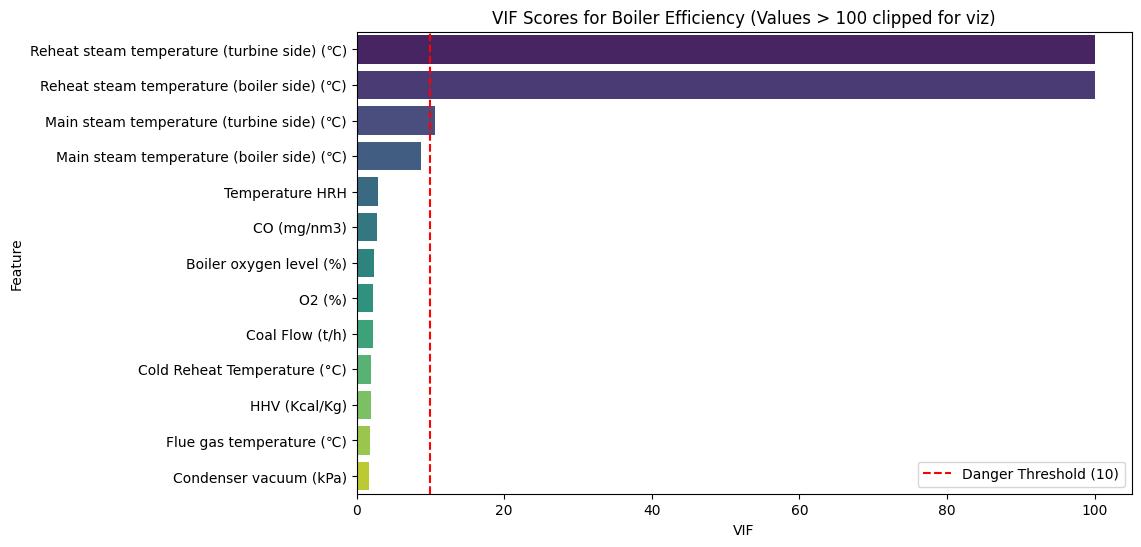

/var/folders/vn/g5ydcdp57s3fp3mg7t_trnvm0000gn/T/ipykernel_27242/542543383.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='VIF', y='Feature', data=vif_nphr.replace(float('inf'), 100), palette='magma')


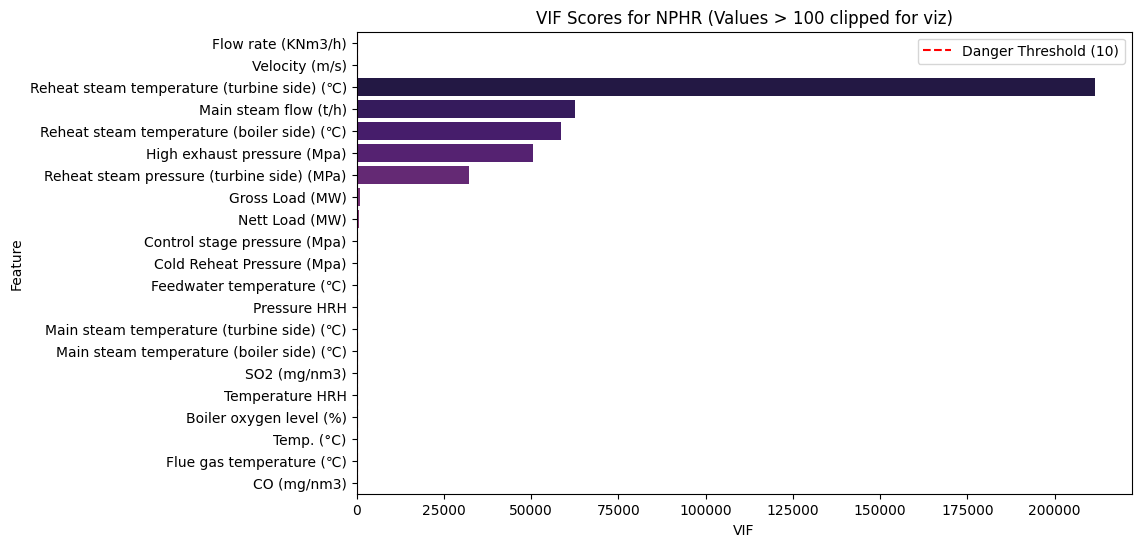

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler

def calculate_vif_scaled(data_frame, feature_list):
    """
    Menghitung VIF setelah melakukan Standard Scaling untuk stabilitas numerik.
    """
    if not feature_list:
        return pd.DataFrame(columns=["Feature", "VIF"])
        
    # 1. Ambil data dan bersihkan NaN
    X = data_frame[feature_list].copy().dropna()
    
    if X.empty:
        return "Dataset kosong setelah dropna()."

    # 2. Standard Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 3. Buat DataFrame baru dari hasil scaling
    X_scaled_df = pd.DataFrame(X_scaled, columns=feature_list)
    
    # 4. Tambahkan konstanta (Intersept)
    X_scaled_df = add_constant(X_scaled_df)
    
    # 5. Hitung VIF
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_scaled_df.columns
    
    vif_list = []
    for i in range(len(X_scaled_df.columns)):
        try:
            vif = variance_inflation_factor(X_scaled_df.values, i)
        except:
            vif = float('inf')
        vif_list.append(vif)
        
    vif_data["VIF"] = vif_list
    
    # Menghapus baris 'const' dan urutkan
    return vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF", ascending=False)

# --- 1. Gabungkan fitur untuk masing-masing model ---
final_inputs_boiler = list(set(shared_features + only_boiler))
final_inputs_nphr = list(set(shared_features + only_nphr))

# --- 2. Hitung VIF untuk Model Boiler ---
print("=== VIF Analysis: Boiler Efficiency Model (Scaled) ===")
vif_boiler = calculate_vif_scaled(df, final_inputs_boiler)
print(vif_boiler)
print("\n")

# --- 3. Hitung VIF untuk Model NPHR ---
print("=== VIF Analysis: NPHR Model (Scaled) ===")
vif_nphr = calculate_vif_scaled(df, final_inputs_nphr)
print(vif_nphr)

# --- 4. Visualisasi VIF (Boiler) ---
plt.figure(figsize=(10, 6))
# Gunakan log scale jika ada nilai INF agar plot tidak hancur
sns.barplot(x='VIF', y='Feature', data=vif_boiler.replace(float('inf'), 100), palette='viridis')
plt.axvline(x=10, color='red', linestyle='--', label='Danger Threshold (10)')
plt.title('VIF Scores for Boiler Efficiency (Values > 100 clipped for viz)')
plt.legend()
plt.show()

# --- 5. Visualisasi VIF (NPHR) ---
plt.figure(figsize=(10, 6))
sns.barplot(x='VIF', y='Feature', data=vif_nphr.replace(float('inf'), 100), palette='magma')
plt.axvline(x=10, color='red', linestyle='--', label='Danger Threshold (10)')
plt.title('VIF Scores for NPHR (Values > 100 clipped for viz)')
plt.legend()
plt.show()

In [18]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def auto_clean_vif(data_frame, feature_list, threshold=10.0):
    """
    Calculates VIF and removes the feature with the highest VIF one by one
    until all features have a VIF < threshold.
    """
    # 1. Prepare data (Drop NaNs)
    X = data_frame[feature_list].copy().dropna()
    
    while True:
        # Add constant for VIF calculation
        X_const = add_constant(X)
        vif_list = []
        for i in range(len(X_const.columns)):
            try:
                # Use scalar divide handling to prevent crashes on 'inf'
                vif = variance_inflation_factor(X_const.values, i)
            except:
                vif = float('inf')
            vif_list.append(vif)
            
        vif_df = pd.DataFrame({'Feature': X_const.columns, 'VIF': vif_list})
        vif_df = vif_df[vif_df['Feature'] != 'const']
        
        max_vif = vif_df['VIF'].max()
        
        # If the highest VIF is still above threshold, drop that feature
        if max_vif > threshold or np.isinf(max_vif):
            feature_to_drop = vif_df.sort_values('VIF', ascending=False)['Feature'].iloc[0]
            print(f"Removing '{feature_to_drop}' (VIF: {max_vif:.2f})")
            X = X.drop(columns=[feature_to_drop])
        else:
            break
            
    return X.columns.tolist(), vif_df

# --- EKSEKUSI PEMBERSIHAN ---

print("=== Cleaning Boiler Model Features ===")
refined_boiler_features, final_vif_boiler = auto_clean_vif(df, final_inputs_boiler)

# Tampilkan Hasil Akhir Boiler
print("\n--- HASIL AKHIR VIF: BOILER EFFICIENCY MODEL ---")
print(final_vif_boiler.sort_values(by="VIF", ascending=False).reset_index(drop=True))

print("\n" + "="*50 + "\n")

print("=== Cleaning NPHR Model Features ===")
refined_nphr_features, final_vif_nphr = auto_clean_vif(df, final_inputs_nphr)

# Tampilkan Hasil Akhir NPHR
print("\n--- HASIL AKHIR VIF: NPHR MODEL ---")
print(final_vif_nphr.sort_values(by="VIF", ascending=False).reset_index(drop=True))

=== Cleaning Boiler Model Features ===
Removing 'Reheat steam temperature (turbine side) (℃)' (VIF: inf)
Removing 'Main steam temperature (turbine side) (℃)' (VIF: 10.63)

--- HASIL AKHIR VIF: BOILER EFFICIENCY MODEL ---
                                       Feature       VIF
0   Reheat steam temperature (boiler side) (℃)  3.354229
1                              Temperature HRH  2.876758
2     Main steam temperature (boiler side) (℃)  2.635147
3                                  CO (mg/nm3)  2.265266
4                      Boiler oxygen level (%)  2.201525
5                              Coal Flow (t/h)  2.052299
6                                       O2 (%)  1.923700
7                                HHV (Kcal/Kg)  1.901742
8                 Cold Reheat Temperature (°C)  1.832861
9                       Condenser vacuum (kPa)  1.751266
10                    Flue gas temperature (℃)  1.738660


=== Cleaning NPHR Model Features ===
Removing 'Flow rate (KNm3/h)' (VIF: inf)
Removing 'Rehea

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


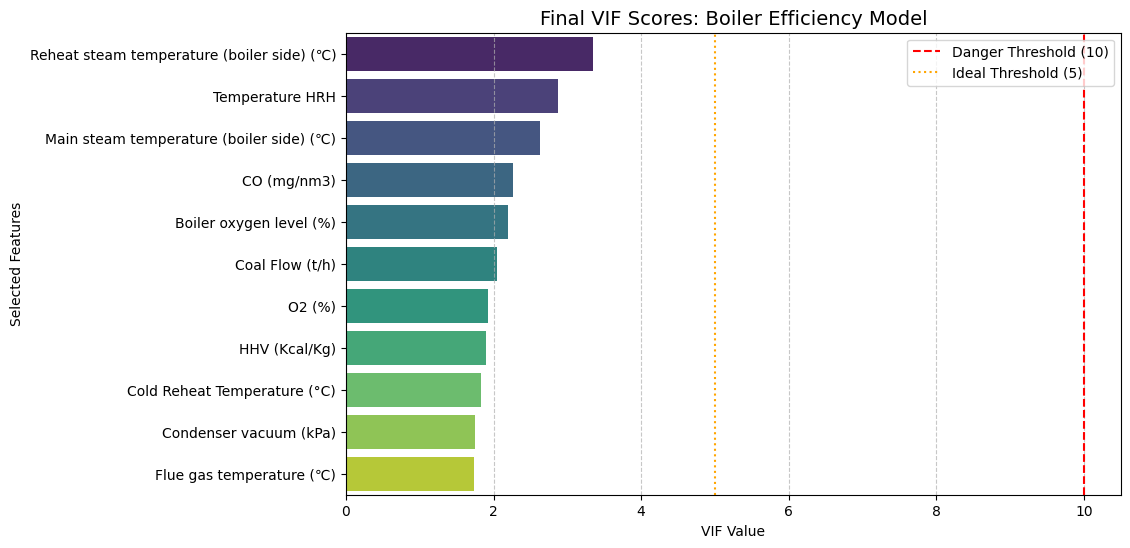

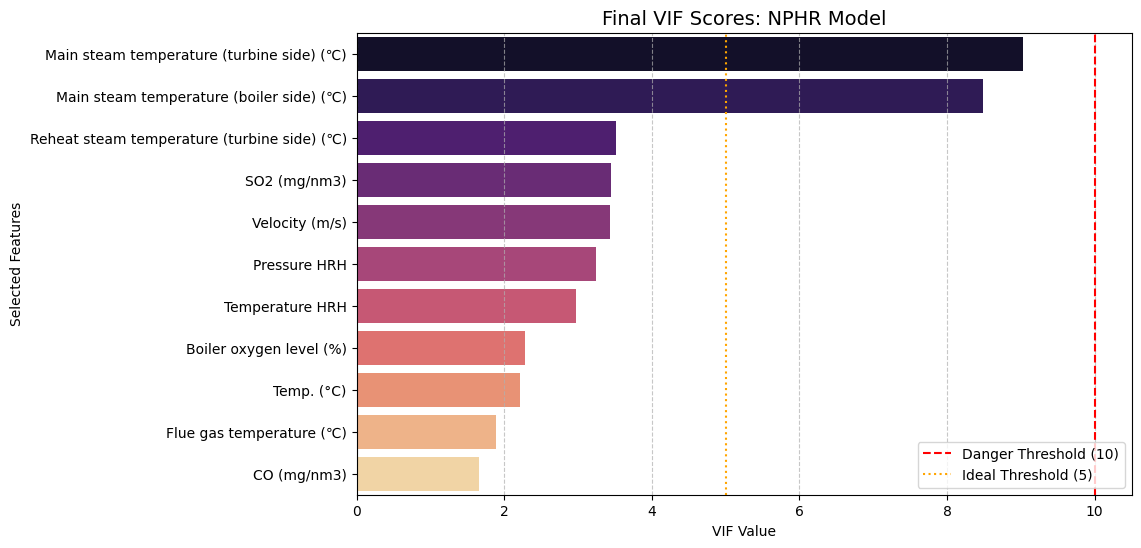

In [19]:
# --- 4. Visualisasi VIF (Boiler) ---
plt.figure(figsize=(10, 6))

# Pastikan data diurutkan agar grafik mudah dibaca
vif_boiler_sorted = final_vif_boiler.sort_values(by='VIF', ascending=False)

# Menggunakan 'hue' untuk menghindari FutureWarning
sns.barplot(
    x='VIF', 
    y='Feature', 
    data=vif_boiler_sorted, 
    hue='Feature', 
    palette='viridis', 
    legend=False
)

plt.axvline(x=10, color='red', linestyle='--', label='Danger Threshold (10)')
plt.axvline(x=5, color='orange', linestyle=':', label='Ideal Threshold (5)')
plt.title('Final VIF Scores: Boiler Efficiency Model', fontsize=14)
plt.xlabel('VIF Value')
plt.ylabel('Selected Features')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# --- 5. Visualisasi VIF (NPHR) ---
plt.figure(figsize=(10, 6))

# Pastikan data diurutkan
vif_nphr_sorted = final_vif_nphr.sort_values(by='VIF', ascending=False)

sns.barplot(
    x='VIF', 
    y='Feature', 
    data=vif_nphr_sorted, 
    hue='Feature', 
    palette='magma', 
    legend=False
)

plt.axvline(x=10, color='red', linestyle='--', label='Danger Threshold (10)')
plt.axvline(x=5, color='orange', linestyle=':', label='Ideal Threshold (5)')
plt.title('Final VIF Scores: NPHR Model', fontsize=14)
plt.xlabel('VIF Value')
plt.ylabel('Selected Features')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [20]:
# --- PENYIMPANAN DATASET FINAL BOILER ---
# 1. Gabungkan fitur input hasil VIF dengan Target Boiler
boiler_final_columns = refined_boiler_features + ['Boiler Eff (%)']
# 2. Filter dataframe asli menggunakan intersection untuk keamanan
df_final_boiler = df[df.columns.intersection(boiler_final_columns)].copy()

# Simpan ke Excel
df_final_boiler.to_excel('#2 final feature selected dataset 6 for boiler efficiency.xlsx', index=False)
print(f"Berhasil menyimpan {len(df_final_boiler.columns)} kolom ke file Boiler.")

# --- PENYIMPANAN DATASET FINAL NPHR ---
# 1. Gabungkan fitur input hasil VIF dengan Target NPHR
nphr_final_columns = refined_nphr_features + ['NPHR (Kcal/Kwh)']
# 2. Filter dataframe asli
df_final_nphr = df[df.columns.intersection(nphr_final_columns)].copy()

# Simpan ke Excel
df_final_nphr.to_excel('#2 final feature selected dataset 6 for nphr.xlsx', index=False)
print(f"Berhasil menyimpan {len(df_final_nphr.columns)} kolom ke file NPHR.")

# --- VALIDASI AKHIR ---
print("\nRingkasan Kolom:")
print(f"Boiler Features: {df_final_boiler.columns.tolist()}")
print(f"NPHR Features: {df_final_nphr.columns.tolist()}")

Berhasil menyimpan 12 kolom ke file Boiler.
Berhasil menyimpan 12 kolom ke file NPHR.

Ringkasan Kolom:
Boiler Features: ['Main steam temperature (boiler side) (℃)', 'Reheat steam temperature (boiler side) (℃)', 'Flue gas temperature (℃)', 'Boiler oxygen level (%)', 'Condenser vacuum (kPa)', 'CO (mg/nm3)', 'O2 (%)', 'Cold Reheat Temperature (°C)', 'Coal Flow (t/h)', 'HHV (Kcal/Kg)', 'Temperature HRH', 'Boiler Eff (%)']
NPHR Features: ['Main steam temperature (boiler side) (℃)', 'Flue gas temperature (℃)', 'Boiler oxygen level (%)', 'Main steam temperature (turbine side) (℃)', 'Reheat steam temperature (turbine side) (℃)', 'SO2 (mg/nm3)', 'CO (mg/nm3)', 'Velocity (m/s)', 'Temp. (°C)', 'NPHR (Kcal/Kwh)', 'Pressure HRH', 'Temperature HRH']
